<h2>RNN with Financial Metrics<h2>

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_project/tesla_stock_data.csv')
data.head()

,Date,Close,High,Low,Open,Volume
0,NaN,TSLA,TSLA,TSLA,TSLA,TSLA
1,2022-02-01,310.4166564941406,314.5666809082031,301.6666564941406,311.7366638183594,73138200
2,2022-02-02,301.88665771484375,310.5,296.4700012207031,309.3933410644531,66792900
3,2022-02-03,297.0466613769531,312.3333435058594,293.50665283203125,294.0,78855600
4,2022-02-04,307.7733459472656,312.1666564941406,293.72332763671875,299.0733337402344,73625400


In [55]:
from sklearn.preprocessing import MinMaxScaler

# drop data column
data = data.drop('Date', axis=1)

# drop the first row
data = data.drop(0, axis=0)

# convert string to float
data = data.astype(float)

scaler = MinMaxScaler(feature_range=(-1, 1))
data = scaler.fit_transform(data)

In [56]:
import torch
import torch.nn as nn

# define the model architecture
class RNN_model(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
    super(RNN_model, self).__init__()
    self.hidden_dim = hidden_dim
    self.num_layers = num_layers
    self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
    out, _ = self.rnn(x, h0)
    return self.fc(out[:, -1, :])

In [57]:
import numpy as np

# function to create sequences of data
def create_sequences(data, sequnece_length):
  sequences = []
  targets = []
  for i in range(len(data) - sequnece_length):
    sequences.append(data[i:i+sequnece_length])
    targets.append(data[i+sequnece_length - 1, 0]) # the target is the next day close price
  return np.array(sequences), np.array(targets)

In [58]:
from itertools import product
import torch.optim as optim

# define grid search parameters
HIDDEN_DIMS = [64, 128]
NUM_LAYERS = [2, 3]
LEARNING_RATES = [0.0001, 0.0003, 0.0005]
BATCH_SIZES = [32, 64]
EPOCHS = [60, 70, 80]
SEQUENCE_LENGTHS = [30, 60]
CRITERIONS = {'MSELoss': nn.MSELoss(), 'SmoothL1Loss': nn.SmoothL1Loss()}
OPTIMISERS = {'Adam': optim.Adam, 'SGD': optim.SGD}

# generate all the possible combinations
parameters_combo = product(HIDDEN_DIMS, NUM_LAYERS, LEARNING_RATES, BATCH_SIZES, EPOCHS, SEQUENCE_LENGTHS, CRITERIONS.items(), OPTIMISERS.items())

# define variables to track the best model
best_model_state = None
best_rmse = float('inf')
best_parameters = {}
best_train_losses = []
best_validation_losses = []
best_train_accuracy = []
best_validation_accuracy = []

In [59]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# run the grid search
for hidden_dim, num_layers, learning_rate, batch_size, epochs, sequence_length, (criterion_name, criterion), (optimiser_name, optimiser) in parameters_combo:
  print(f"***Testing with hidden_dim={hidden_dim}, num_layers={num_layers}, learning_rate={learning_rate}, batch_size={batch_size}, epochs={epochs}, seq_length={sequence_length}, criterion={criterion_name}, optimiser={optimiser_name}")

  # create seqeunces
  X, y = create_sequences(data, sequence_length)

  # split the dataset (66% for training, 20% for testing, 14% for validation)
  train_size = int(len(X) * 0.66)
  validation_size = int(len(X) * 0.14)
  X_train, X_validation, X_test = X[:train_size], X[train_size:train_size+validation_size], X[train_size+validation_size:]
  y_train, y_validation, y_test = y[:train_size], y[train_size:train_size+validation_size], y[train_size+validation_size:]

  # convvert them to tensor
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
  X_validation_tensor = torch.tensor(X_validation, dtype=torch.float32)
  y_validation_tensor = torch.tensor(y_validation, dtype=torch.float32)

  # define data loaders
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
  test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
  validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
  validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

  # initialise the model and optimiser
  model = RNN_model(X_train_tensor.shape[2], hidden_dim, num_layers, 1)
  optimiser = optimiser(model.parameters(), lr=learning_rate)

  train_losses = []
  validation_losses = []
  train_accuracy = []
  validation_acuracy = []

  # train the model
  for epoch in range(epochs):
    model.train()
    running_loss = 0
    y_train_prediction_list, y_train_true_list = [], []

    for X_batch, y_batch in train_loader:
      optimiser.zero_grad()
      outputs = model(X_batch).squeeze()
      loss = criterion(outputs, y_batch)
      loss.backward()
      optimiser.step()
      running_loss += loss.item()

      # track training prediction and true values for accuracy
      y_train_prediction_list.append(outputs.detach().numpy())
      y_train_true_list.append(y_batch.numpy())

    # calculate average training loss
    train_loss_avg = running_loss / len(train_loader)
    train_losses.append(train_loss_avg)

    # calculate training R2 (accuracy)
    y_train_true = np.concatenate(y_train_true_list, axis=0)
    y_train_prediction = np.concatenate(y_train_prediction_list, axis=0)
    train_r2 = r2_score(y_train_true, y_train_prediction)
    train_accuracy.append(train_r2)

    # validation
    model.eval()
    validation_loss = 0
    y_validation_prediction_list, y_validation_true_list = [], []

    with torch.no_grad():
      for X_batch, y_batch in validation_loader:
        validation_outputs = model(X_batch).squeeze()
        loss = criterion(validation_outputs, y_batch)
        validation_loss += loss.item()

        # track validation prediction and true values for accuracy
        y_validation_prediction_list.append(validation_outputs.numpy())
        y_validation_true_list.append(y_batch.numpy())

    # calculate average validation loss
    avg_validation_loss = validation_loss / len(validation_loader)
    validation_losses.append(avg_validation_loss)

    # calculate validation accuracy (R2)
    y_validation_true = np.concatenate(y_validation_true_list, axis=0)
    y_validation_prediction = np.concatenate(y_validation_prediction_list, axis=0)
    validation_r2 = r2_score(y_validation_true, y_validation_prediction)
    validation_acuracy.append(validation_r2)

  # find the best model
  current_rmse = np.sqrt(mean_squared_error(y_validation_true, y_validation_prediction))
  if current_rmse < best_rmse:
    best_rmse = current_rmse
    best_model = model.state_dict()
    best_parameters = {
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'epochs': epochs,
        'sequence_length': sequence_length,
        'criterion': criterion_name,
        'optimiser': optimiser_name,
        'val_rmse': current_rmse,
        'val_mae': mean_absolute_error(y_validation_true, y_validation_prediction),
        'val_r2': validation_r2
    }
    # update loss and accuracy
    best_train_losses = train_losses.copy()
    best_validation_losses = validation_losses.copy()
    best_train_accuracy = train_accuracy.copy()
    best_validation_accuracy = validation_acuracy.copy()

print('best mdoel parameters:', best_parameters)
torch.save(best_model, '/content/drive/MyDrive/Colab Notebooks/final_project/rnn_model_with_financial_metrics.pth')

***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=30, criterion=MSELoss, optimiser=Adam
***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=30, criterion=MSELoss, optimiser=SGD
***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=30, criterion=SmoothL1Loss, optimiser=Adam
***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=30, criterion=SmoothL1Loss, optimiser=SGD
***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=60, criterion=MSELoss, optimiser=Adam
***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=60, criterion=MSELoss, optimiser=SGD
***Testing with hidden_dim=64, num_layers=2, learning_rate=0.0001, batch_size=32, epochs=60, seq_length=60, criterion=SmoothL1Loss, optimiser

In [60]:
# load the best model and re-evaluate it
best_model = RNN_model(input_dim=X_test_tensor.shape[2],
                       hidden_dim=best_parameters['hidden_dim'],
                       num_layers=best_parameters['num_layers'],
                       output_dim=1)
best_model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/final_project/rnn_model_with_financial_metrics.pth'))

# prediction
best_model.eval()
y_true_lst = []
y_hat_lst = []
with torch.no_grad():
  for X_batch, y_batch in test_loader:
    pred_batch = best_model(X_batch).numpy()
    y_hat_lst.append(pred_batch)
    y_true_lst.append(y_batch.numpy())

# convert the lists to arrays
y_true = np.concatenate(y_true_lst, axis=0).squeeze()
y_hat = np.concatenate(y_hat_lst, axis=0).squeeze()

# the prediction should be converted into its original scale before noramlisation
# to see results in the real world prices
y_true_org = scaler.inverse_transform(np.column_stack((y_true, np.zeros((y_true.shape[0], 4)))))[:, 0]
y_hat_org = scaler.inverse_transform(np.column_stack((y_hat, np.zeros((y_hat.shape[0], 4)))))[:, 0]

mse_original = mean_squared_error(y_true_org, y_hat_org)
rmse_original = np.sqrt(mse_original)
mae_original = mean_absolute_error(y_true_org, y_hat_org)
r2_original = r2_score(y_true_org, y_hat_org)

print("best model evaluation:")
print(f"MSE: {mse_original:.4f}")
print(f"RMSE: {rmse_original:.4f}")
print(f"MAE: {mae_original:.4f}")
print(f"R² Score: {r2_original:.4f}")

best model evaluation:
MSE: 46.5608
RMSE: 6.8235
MAE: 4.3607
R² Score: 0.9932


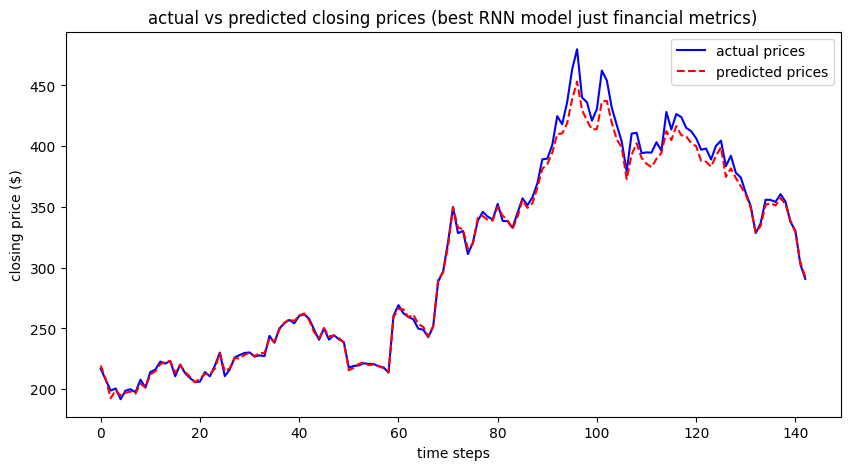

In [61]:
import matplotlib.pyplot as plt

# plot actual prices vs predicted prices
plt.figure(figsize=(10,5))
plt.plot(y_true_org, label="actual prices", color='blue')
plt.plot(y_hat_org, label="predicted prices", color='red', linestyle='dashed')
plt.legend()
plt.title("actual vs predicted closing prices (best RNN model just financial metrics)")
plt.xlabel("time steps")
plt.ylabel("closing price ($)")
plt.show()

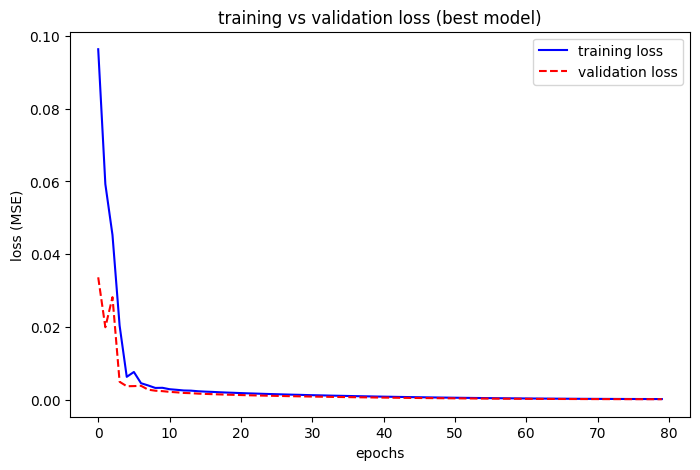

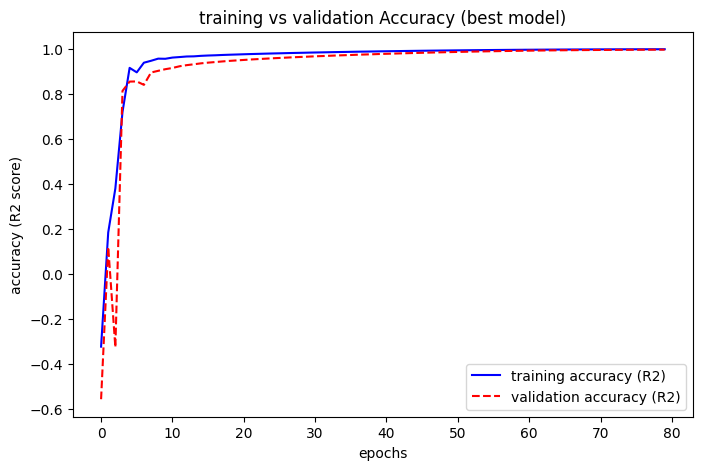

In [62]:
# plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(best_train_losses, label="training loss", color='blue')
plt.plot(best_validation_losses, label="validation loss", color='red', linestyle='dashed')
plt.xlabel("epochs")
plt.ylabel("loss (MSE)")
plt.legend()
plt.title("training vs validation loss (best model)")
plt.show()

# plot training vs validation accuracy (R2 score)
plt.figure(figsize=(8,5))
plt.plot(best_train_accuracy, label="training accuracy (R2)", color='blue')
plt.plot(best_validation_accuracy, label="validation accuracy (R2)", color='red', linestyle='dashed')
plt.xlabel("epochs")
plt.ylabel("accuracy (R2 score)")
plt.legend()
plt.title("training vs validation Accuracy (best model)")
plt.show()